## **Setup**

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [2]:
import time
import math
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import copy

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize
from chatGnT.models import transformer, positional_encoding, train, evaluate, predict
import chatGnT.utils as utils

ensure_dirs(CFG)

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Load & Clean Data**

In [3]:
data = load.load_all()
df = data["ingred"]
df_clean = preprocess.clean_recipes(df)
df_clean_filt = preprocess.filter_recipes(df_clean)

## **Make Vocab & Tokenize**

In [4]:

tokens = tokenize.recipe_to_tokens(df_clean_filt)
print(tokens[0:1])


[['<amt>1 oz</amt>', '<ingred>coconut-rum</ingred>', '<amt>0.5 oz</amt>', '<ingred>amaretto</ingred>', '<amt>4 oz</amt>', '<ingred>orange-juice</ingred>', '<amt>0.5 oz</amt>', '<ingred>grenadine</ingred>']]


In [5]:
vocab = tokenize.make_vocab(tokens)
print(len(vocab))  # 563 classes to predict
inv_vocab = tokenize.invert_vocab(vocab)
tokens_padded = tokenize.embed_tokens(tokens, vocab)

563


In [6]:
# Check vocab and padded tokens
print("Vocabulary:", vocab)
print("Padded Tokens:", tokens_padded[0])

Vocabulary: {'<amt>0.125 l</amt>': 1, '<amt>0.125 shot</amt>': 2, '<amt>0.125 tsp</amt>': 3, '<amt>0.16666666666666666 glass</amt>': 4, '<amt>0.2 part</amt>': 5, '<amt>0.25 cl</amt>': 6, '<amt>0.25 cup</amt>': 7, '<amt>0.25 glass</amt>': 8, '<amt>0.25 oz</amt>': 9, '<amt>0.25 part</amt>': 10, '<amt>0.25 shot</amt>': 11, '<amt>0.25 tsp</amt>': 12, '<amt>0.25</amt>': 13, '<amt>0.3333333333333333 cup</amt>': 14, '<amt>0.3333333333333333 oz</amt>': 15, '<amt>0.3333333333333333 part</amt>': 16, '<amt>0.3333333333333333 shot</amt>': 17, '<amt>0.4 part</amt>': 18, '<amt>0.5 can</amt>': 19, '<amt>0.5 cup</amt>': 20, '<amt>0.5 gal</amt>': 21, '<amt>0.5 glass</amt>': 22, '<amt>0.5 jigger</amt>': 23, '<amt>0.5 kg</amt>': 24, '<amt>0.5 l</amt>': 25, '<amt>0.5 lb</amt>': 26, '<amt>0.5 oz</amt>': 27, '<amt>0.5 part</amt>': 28, '<amt>0.5 piece</amt>': 29, '<amt>0.5 pint</amt>': 30, '<amt>0.5 shot</amt>': 31, '<amt>0.5 slice</amt>': 32, '<amt>0.5 tsp</amt>': 33, '<amt>0.5</amt>': 34, '<amt>0.666666666

In [7]:
# tokens_tensor = [torch.tensor(r) for r in tokens_padded]
tokens_tensor = torch.tensor(tokens_padded, dtype=torch.long)
print(tokens_tensor.shape)  # torch.Size([621, 48])


torch.Size([596, 25])


## **Get Batches**

In [10]:
inputs = tokens_tensor[:, :-1]
targets = tokens_tensor[:, 1:]

dataset = TensorDataset(inputs, targets)
dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print(dataloader.batch_size)  # 32
print(len(dataloader))  # 19 = 596 / 32


32
19


## **Train Model**

In [11]:
embed_size=16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformer.TransformerModel(
    ntoken=len(vocab),
    ninp=embed_size,
    nhead=4,
    nhid=256,
    nlayers=2).to(device)
# Note warning:
# UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is
# False because encoder_layer.self_attn.batch_first was not True (use
# # batch_first for better inference performance)

pad_id = vocab["<pad>"]
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)
#TODO: read more about scheduler

/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


In [12]:
epochs = 100  # number of epochs

# Initialize trackers
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model = None

# Early Stopping parameters
patience = 5  # Stop if no improvement for 5 epochs
trigger_times = 0 

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()

    avg_train_loss = train.train(model, dataloader, device, pad_id, optimizer, criterion, epoch, 6)
    train_losses.append(avg_train_loss)

    val_loss = evaluate.evaluate(model, dataloader, device, pad_id, criterion)
    val_losses.append(val_loss)

    print('-' * 89)
    print(
        f'Epoch {epoch} | Val Loss: {val_loss:.4f} | '
        f'Time {(time.time() - epoch_start_time)} | Val PPL: {math.exp(val_loss):.2f}')
    print('-' * 89)

    # 3. Early Stopping & Best Model Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        best_model = model
    else:
        trigger_times += 1
        print(f'No improvement. Early stopping counter: {trigger_times}/{patience}')
        if trigger_times >= patience:
            print("Early stopping triggered. Ending training.")
            break

    scheduler.step()  # adjusts learning rate
    #TODO: read more about this?


/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1 | Batch 6 | LR 0.001000 | Loss 7.4002 | PPL 1636.33 | Time 0.15s
Epoch 1 | Batch 12 | LR 0.001000 | Loss 6.2554 | PPL 520.83 | Time 0.11s
Epoch 1 | Batch 18 | LR 0.001000 | Loss 6.1873 | PPL 486.51 | Time 0.11s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 6.0944 | Time 0.45033884048461914 | Val PPL: 443.35
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000950 | Loss 7.1342 | PPL 1254.08 | Time 0.13s
Epoch 2 | Batch 12 | LR 0.000950 | Loss 6.0641 | PPL 430.13 | Time 0.12s
Epoch 2 | Batch 18 | LR 0.000950 | Loss 5.9856 | PPL 397.66 | Time 0.11s
-----------------------------------------------------------------------------------------
Epoch 2 | Val Loss: 5.8800 | Time 0.45964574813842773 | Val PPL: 357.81
-----------------------------------------------------------------------------------------
Epoch 3 | Batch 6 | LR 0.000902 | Loss 6.9038 | PPL 996.09

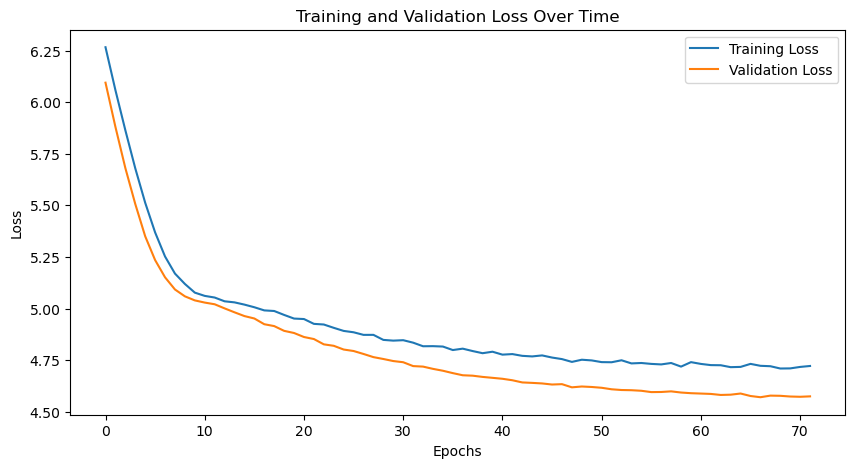

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

## **Run with Test User Input**

In [17]:
#TODO: for now just manually making token, but need to handle actual format
# of user input


# input_mod = ['<amt>1 oz</amt>', '<ingred>gin</ingred>']
input_mod = ["<amt>1 oz</amt>", "<ingred>gin</ingred>"]

In [19]:
predict.predict(best_model, device, pad_id, vocab, inv_vocab, input_mod)


['<amt>1 oz</amt>',
 '<ingred>gin</ingred>',
 '<amt>dash</amt>',
 '<amt>1 tblsp</amt>',
 '<ingred>maraschino-liqueur</ingred>',
 '<ingred>orange-peel</ingred>',
 '<amt>0.5 tsp</amt>',
 '<ingred>whipped-cream</ingred>',
 '<end>']